Loaded data shape: (25328, 33)
Number of channels: 33
Trimmed to 32 channels (0-31): (25328, 32)


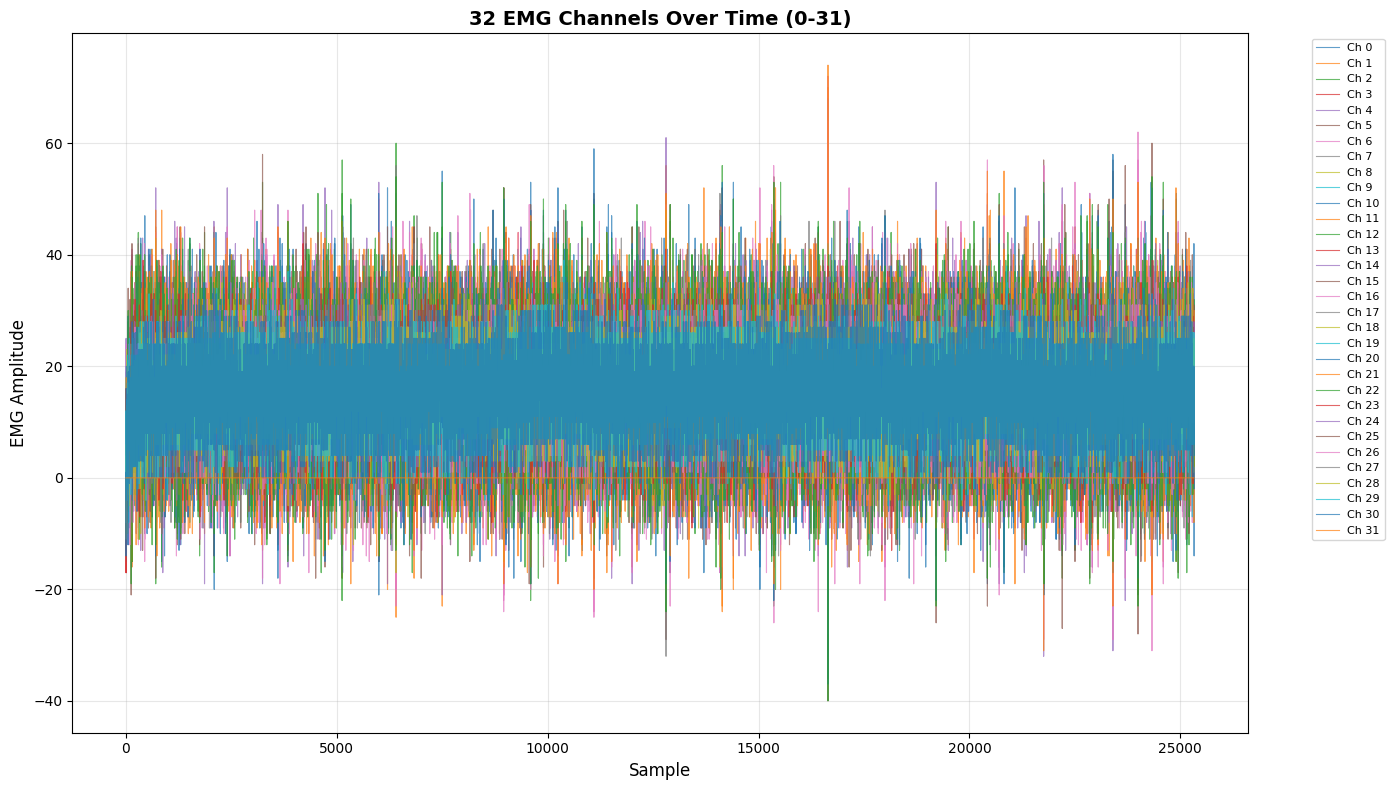

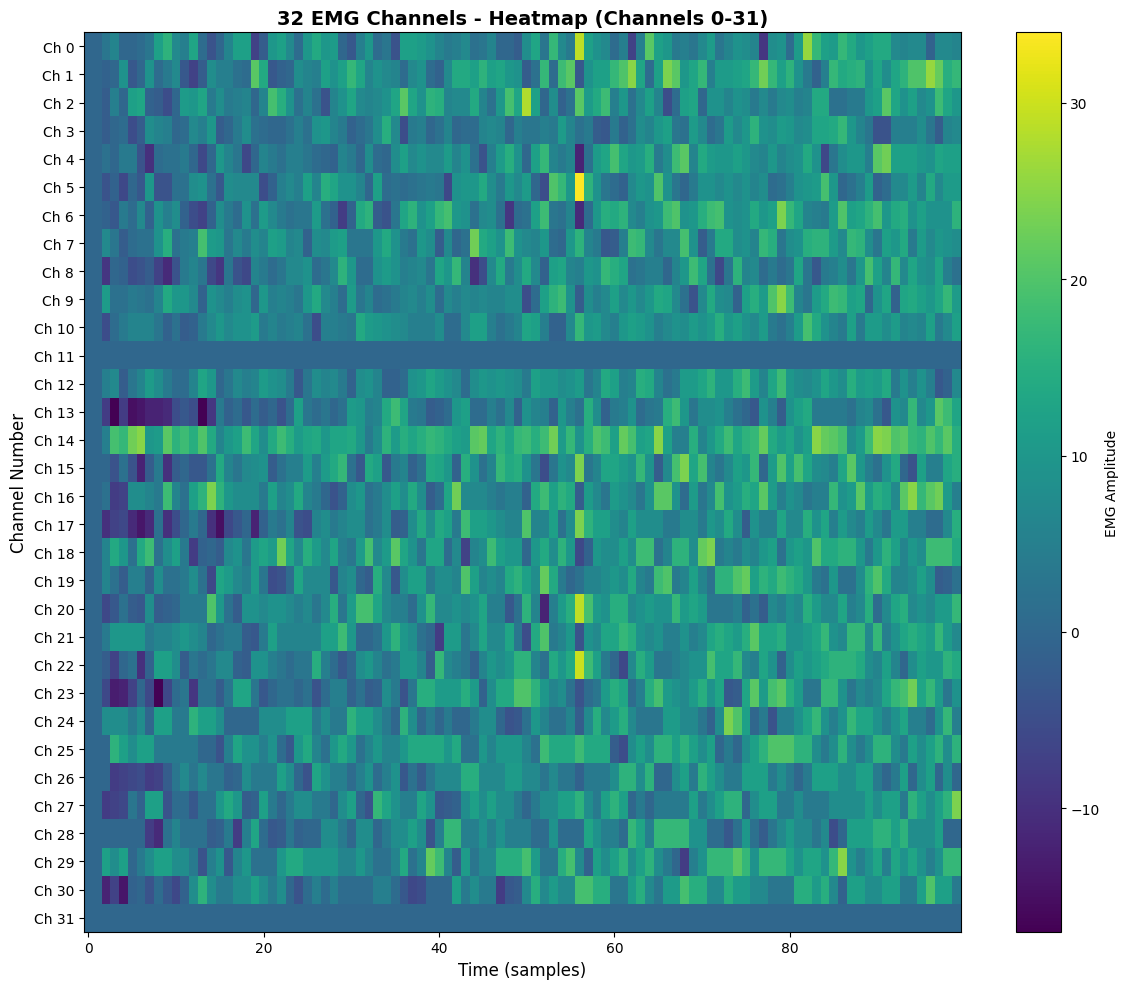

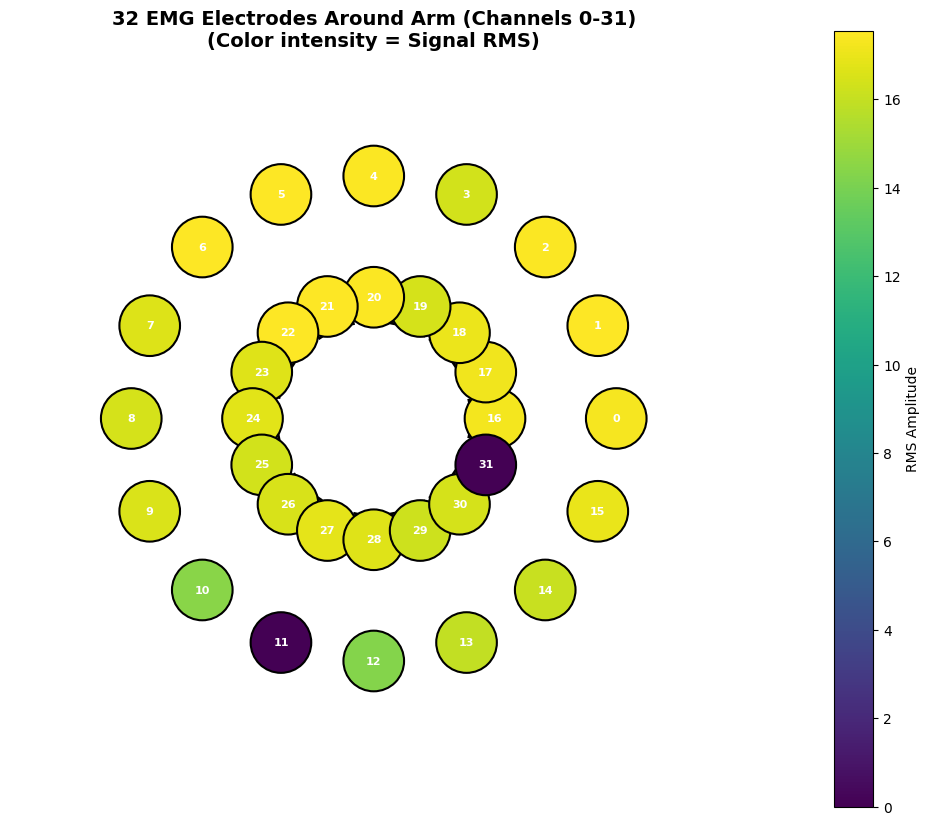


Data exported to 'emg_data_32channels.csv' with shape (25328, 32)
   Channel_0  Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0        0.0        0.0        0.0        0.0   
2        3.0       -1.0       -2.0       -2.0        2.0       -4.0   
3        6.0        0.0        5.0        0.0        0.0       -1.0   
4        0.0        9.0        0.0        1.0        4.0       -6.0   

   Channel_6  Channel_7  Channel_8  Channel_9  ...  Channel_22  Channel_23  \
0        0.0        0.0        0.0        0.0  ...         0.0         0.0   
1        0.0        0.0        0.0        0.0  ...         0.0         0.0   
2       -1.0        7.0       -9.0       11.0  ...        -2.0        -6.0   
3       -3.0        3.0        0.0        2.0  ...        -7.0       -13.0   
4        4.0       -2.0       -1.0        2.0  ...         0.0       -12.0   

   Channel_24  Channel_25  Channel_26

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# Load EMG data from session file
session_file = Path("/home/fire/Documents/gitwork/EMG_Exo/md-emg-python/data/healthy/S0/emg_logs/session_00.npy")

# Load all arrays from the npy file
arrays = []
with open(session_file, 'rb') as f:
    while True:
        try:
            arrays.append(np.load(f, allow_pickle=False))
        except (ValueError, EOFError):
            break

# Concatenate all buffers into single array (time x channels)
data = np.concatenate(arrays, axis=0)
print(f"Loaded data shape: {data.shape}")
print(f"Number of channels: {data.shape[1] if data.ndim > 1 else 1}")

# Ensure we only use channels 0-31 (first 32 channels)
if data.ndim > 1 and data.shape[1] > 32:
    data = data[:, :32]
    print(f"Trimmed to 32 channels (0-31): {data.shape}")

n_channels = data.shape[1] if data.ndim > 1 else 1

# ============ Plot 1: Line plot of all EMG channels ============
fig, ax = plt.subplots(figsize=(14, 8))

# Plot each channel as a separate line
if data.ndim > 1:
    for ch in range(n_channels):
        ax.plot(data[:, ch], label=f'Ch {ch}', alpha=0.7, linewidth=0.8)
else:
    ax.plot(data, label='Channel 0', alpha=0.7)

ax.set_xlabel("Sample", fontsize=12)
ax.set_ylabel("EMG Amplitude", fontsize=12)
ax.set_title(f"{n_channels} EMG Channels Over Time (0-{n_channels-1})", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

# ============ Plot 2: Heatmap - channels arranged around arm ============
# Create a circular layout for electrodes surrounding the arm
# Sample timepoints for heatmap visualization
n_samples_display = min(100, data.shape[0])
heatmap_data = data[:n_samples_display, :] if data.ndim > 1 else data[:n_samples_display]

fig, ax = plt.subplots(figsize=(12, 10))

# Display heatmap as time x channels
if data.ndim > 1:
    im = ax.imshow(heatmap_data.T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_yticks(range(n_channels))
    ax.set_yticklabels([f'Ch {i}' for i in range(n_channels)])
else:
    im = ax.imshow(heatmap_data.reshape(-1, 1).T, aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_yticks([0])
    ax.set_yticklabels(['Ch 0'])

ax.set_xlabel("Time (samples)", fontsize=12)
ax.set_ylabel("Channel Number", fontsize=12)
ax.set_title(f"{n_channels} EMG Channels - Heatmap (Channels 0-{n_channels-1})", fontsize=14, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='EMG Amplitude')
plt.tight_layout()
plt.show()

# ============ Plot 3: Circular arm electrode visualization ============
if data.ndim > 1 and n_channels >= 16:
    # Arrange electrodes in a circular pattern around the arm
    fig, ax = plt.subplots(figsize=(10, 10))

    inner_radius = 1.0
    outer_radius = 2.0

    # Create two rings (inner and outer) for realistic arm electrode sleeve
    # Distribute channels evenly across both rings
    n_per_ring = n_channels // 2
    angles = np.linspace(0, 2*np.pi, n_per_ring, endpoint=False)

    positions = []
    # Outer ring (first half of channels)
    for i in range(n_per_ring):
        x_outer = outer_radius * np.cos(angles[i])
        y_outer = outer_radius * np.sin(angles[i])
        positions.append((x_outer, y_outer))

    # Inner ring (second half of channels)
    for i in range(n_channels - n_per_ring):
        angle_idx = i if i < len(angles) else i % len(angles)
        x_inner = inner_radius * np.cos(angles[angle_idx])
        y_inner = inner_radius * np.sin(angles[angle_idx])
        positions.append((x_inner, y_inner))

    # Use RMS (root mean square) of each channel as intensity for color coding
    rms_values = np.sqrt(np.mean(data**2, axis=0))
    rms_normalized = (rms_values - rms_values.min()) / (rms_values.max() - rms_values.min() + 1e-8)

    # Plot arm circle (outline)
    arm_circle = patches.Circle((0, 0), inner_radius * 0.8, fill=False, edgecolor='black', linewidth=2, linestyle='--', label='Arm')
    ax.add_patch(arm_circle)

    # Plot electrodes as circles with color intensity based on RMS
    for i, (x, y) in enumerate(positions):
        color_intensity = rms_normalized[i]
        circle = patches.Circle((x, y), 0.25, color=plt.cm.viridis(color_intensity), ec='black', linewidth=1.5)
        ax.add_patch(circle)
        ax.text(x, y, f'{i}', ha='center', va='center', fontsize=8, fontweight='bold', color='white')

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"{n_channels} EMG Electrodes Around Arm (Channels 0-{n_channels-1})\n(Color intensity = Signal RMS)", fontsize=14, fontweight='bold')

    # Add colorbar-like reference
    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=rms_values.min(), vmax=rms_values.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.8, label='RMS Amplitude')
    plt.tight_layout()
    plt.show()
else:
    print(f"Skipping circular visualization (requires at least 16 channels, found {n_channels})")

# ============ Export to CSV ============
if data.ndim > 1:
    df = pd.DataFrame(data, columns=[f'Channel_{i}' for i in range(n_channels)])
else:
    df = pd.DataFrame(data, columns=['Channel_0'])
    
df.to_csv("emg_data_32channels.csv", index=False)
print(f"\nData exported to 'emg_data_32channels.csv' with shape {df.shape}")
print(df.head())
